In [1]:
import networkx as nx
from qaoa_old import *
import itertools

In [2]:
# Produce all binary strings of length n with k 1s. If k is None, produce all possible binary strings of length n.
def get_binary_strings(n, k=None):
    """
    Produce all binary strings of length n with k 1s.
    Returns a list of binary lists.
    """
    final = []

    def kbits(r):
        result = []
        for bits in itertools.combinations(range(n), r):
            s = [0] * n
            for bit in bits:
                s[bit] = 1
            result.append(s)
        return result

    if k is not None:
        return kbits(k)

    for i in range(n + 1):
        final += kbits(i)

    return final

In [3]:
def count_solutions_XI(Operator, tol=1e-10):
    """
    Count X/I Pauli string in the operator decomposition.

    Args:
        Operator (np.array): Operator matrix.
        tol (float, optional): Tolerance. Defaults to 1e-10.

    Returns:
        tuple: X/I solutions, max locality, average locality, and the number of solutions.
    """
    nqubits = int(np.log2(len(Operator)))
    x_strings = get_binary_strings(nqubits)
    z_zeros = np.zeros(nqubits)

    ans = []
    max_locality = 0
    avg_locality = 0.0

    for i in x_strings:
        x_mat = w_operator(i, z_zeros)
        coef = np.around(1 / (1 << nqubits) * np.real(np.trace(x_mat @ Operator)), 6)
        if np.abs(coef) > tol:
            count_x = np.sum(i)
            ans.append((str(i), coef))
            if count_x > max_locality:
                max_locality = count_x
            avg_locality += count_x

    len_ans = len(ans)
    if len_ans == 0:
        len_ans = 1

    return ans, max_locality, avg_locality / len_ans, len_ans
def color_nodes_by_string(graph, color_string):
    """
    Color nodes in a graph based on the values in a string.

    Args:
    - graph (NetworkX graph): The graph to be colored.
    - color_string (str): A string representing the node colors.

    Returns:
    - None
    """
    # Convert color string to list of integers
    color_values = [int(char) for char in color_string.strip('[]').split(', ')]

    # Map color values to colors
    node_colors = ['grey' if value == 0 else 'red' for value in color_values]

    # Draw the graph with colored nodes
    nx.draw_networkx(graph, node_color=node_colors)
    plt.show()

In [4]:
count_solutions_XI(np.array([[0,1],[1,0]]))

([('[1]', 1.0)], 1, 1.0, 1)

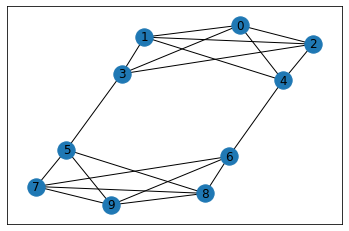

In [5]:

edges = [[0, 1],
 [0, 2],
 [0, 3],
 [0, 4],
 [1, 0],
 [1, 2],
 [1, 3],
 [1, 4],
 [2, 0],
 [2, 1],
 [2, 3],
 [2, 4],
 [3, 0],
 [3, 1],
 [3, 2],
 [3, 5],
 [4, 0],
 [4, 1],
 [4, 2],
 [4, 6],
 [5, 3],
 [5, 7],
 [5, 8],
 [5, 9],
 [6, 4],
 [6, 7],
 [6, 8],
 [6, 9],
 [7, 5],
 [7, 6],
 [7, 8],
 [7, 9],
 [8, 5],
 [8, 6],
 [8, 7],
 [8, 9],
 [9, 5],
 [9, 6],
 [9, 7],
 [9, 8]]

G = nx.from_edgelist(edges)
nx.draw_networkx(G)

In [8]:

# Step 2: Create the Hamiltonian for the graph
H = Graph_to_Hamiltonian(nx.adjacency_matrix(G).todense().tolist())
qaoa = QAOA(4, H)


# 3,5

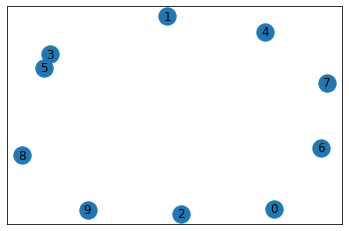

In [8]:
# Step 3: Create a subgraph for a smaller problem, i.e. term of the Hamilotian.
G1 = nx.Graph()
G1.add_nodes_from(range(10)) # Note that numeration should be the same
G1.add_edge(5, 3)

# Visualize the subgraph (optional)
nx.draw_networkx(G1)


In [9]:
# Step 4: Create the Hamiltonian for the subgraph
H1 = Graph_to_Hamiltonian(nx.adjacency_matrix(G1).todense().tolist())


In [22]:
qaoa = QAOA(4, H)

In [23]:
# Step 5: Construct the QAOA operator for two layers
# Note: You can adjust the number of layers as needed
angles = np.random.rand(qaoa.p*2) * np.pi
op = qaoa.construct_QAOA_operator_term(angles, part_hamiltonian=H1)



In [24]:
# Step 6: Count the X/I solutions and other statistics
x_i_solutions, max_locality, avg_locality, num_solutions = count_solutions_XI(op, tol=1e-6)


In [25]:
print("\nX/I Solutions:")
for i in x_i_solutions:
    print(i)
print("Number of X/I Solutions:", num_solutions)
print("Maximum Locality:", max_locality)
print("Average Locality:", avg_locality)


X/I Solutions:
('[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]', -0.021312)
('[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]', -0.021312)
('[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]', -0.021312)
('[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]', -0.028256)
('[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]', 0.000133)
('[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]', -0.028256)
('[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]', 0.000133)
('[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]', -0.021312)
('[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]', -0.021312)
('[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]', -0.021312)
('[1, 1, 0, 0, 0, 0, 0, 0, 0, 0]', -0.00075)
('[1, 0, 1, 0, 0, 0, 0, 0, 0, 0]', -0.00075)
('[1, 0, 0, 1, 0, 0, 0, 0, 0, 0]', 7.6e-05)
('[1, 0, 0, 0, 1, 0, 0, 0, 0, 0]', 0.000267)
('[1, 0, 0, 0, 0, 1, 0, 0, 0, 0]', 0.000919)
('[1, 0, 0, 0, 0, 0, 1, 0, 0, 0]', 3.3e-05)
('[1, 0, 0, 0, 0, 0, 0, 1, 0, 0]', -0.000916)
('[1, 0, 0, 0, 0, 0, 0, 0, 1, 0]', -0.000916)
('[1, 0, 0, 0, 0, 0, 0, 0, 0, 1]', -0.000916)
('[0, 1, 1, 0, 0, 0, 0, 0, 0, 0]', -0.00075)
('[0, 1, 0, 1, 0, 0, 0, 0, 0, 0]', 7.6e-05)
('[0, 1, 0, 0, 1, 0, 0, 0, 0, 0

In [27]:
# Sort by the absolute value of the coefficient
sorted_x_i_solutions = sorted(x_i_solutions, key=lambda x: abs(x[1]), reverse=True)

# Print the sorted list
for solution in sorted_x_i_solutions:
    print(solution)

('[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]', -0.028256)
('[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]', -0.028256)
('[1, 1, 1, 0, 0, 0, 0, 0, 0, 0]', 0.023918)
('[0, 0, 0, 0, 0, 0, 0, 1, 1, 1]', 0.023918)
('[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]', -0.021312)
('[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]', -0.021312)
('[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]', -0.021312)
('[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]', -0.021312)
('[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]', -0.021312)
('[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]', -0.021312)
('[1, 1, 0, 1, 0, 0, 0, 0, 0, 0]', 0.007826)
('[1, 0, 1, 1, 0, 0, 0, 0, 0, 0]', 0.007826)
('[0, 1, 1, 1, 0, 0, 0, 0, 0, 0]', 0.007826)
('[0, 0, 0, 0, 0, 1, 0, 1, 1, 0]', 0.007826)
('[0, 0, 0, 0, 0, 1, 0, 1, 0, 1]', 0.007826)
('[0, 0, 0, 0, 0, 1, 0, 0, 1, 1]', 0.007826)
('[1, 1, 1, 1, 0, 0, 0, 0, 0, 0]', 0.005096)
('[0, 0, 0, 0, 0, 1, 0, 1, 1, 1]', 0.005096)
('[1, 1, 1, 1, 0, 0, 0, 1, 1, 0]', 0.003175)
('[1, 1, 1, 1, 0, 0, 0, 1, 0, 1]', 0.003175)
('[1, 1, 1, 1, 0, 0, 0, 0, 1, 1]', 0.003175)
('[1, 1, 0, 0, 0, 1, 0, 1, 1, 1]', 0.003175)
('

coef: -0.028256


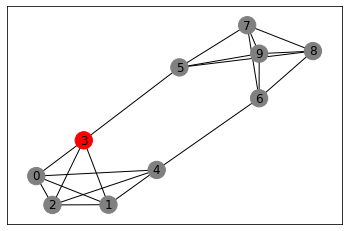

coef: -0.028256


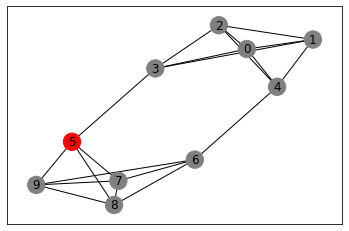

coef: 0.023918


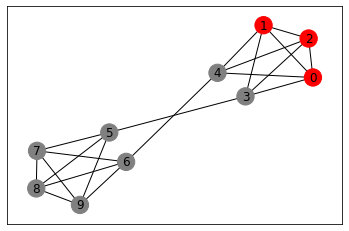

coef: 0.023918


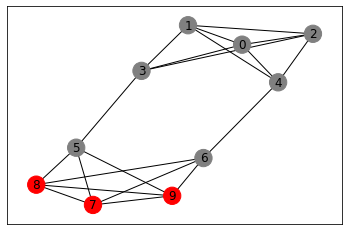

coef: -0.021312


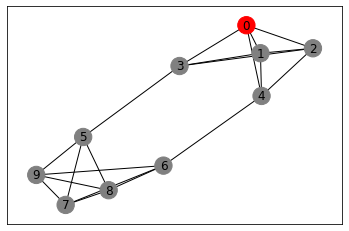

coef: -0.021312


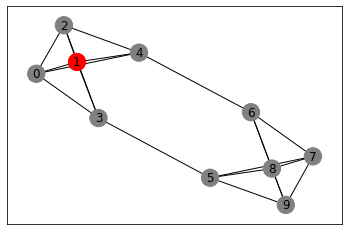

coef: -0.021312


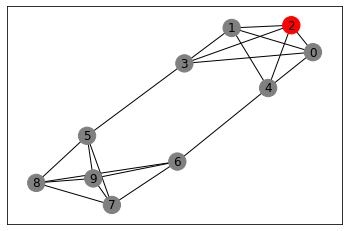

coef: -0.021312


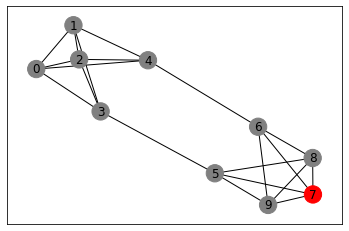

coef: -0.021312


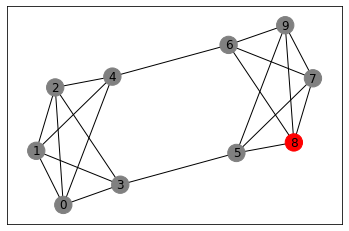

coef: -0.021312


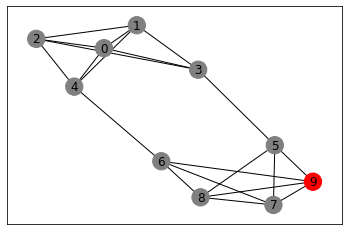

coef: 0.007826


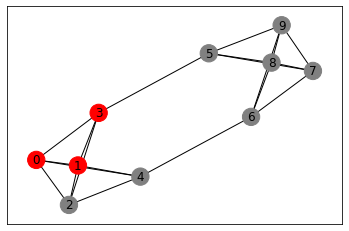

coef: 0.007826


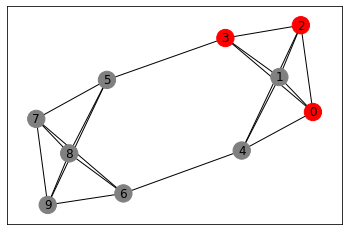

coef: 0.007826


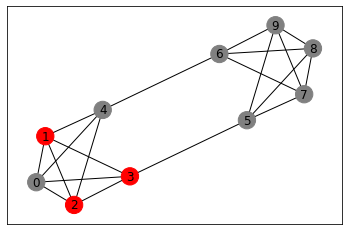

coef: 0.007826


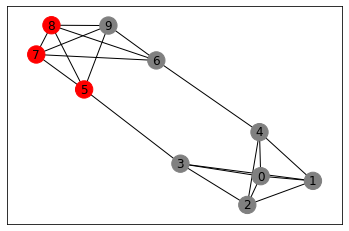

coef: 0.007826


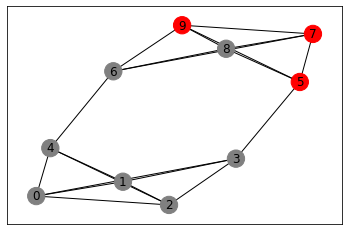

coef: 0.007826


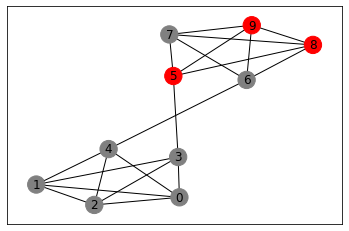

coef: 0.005096


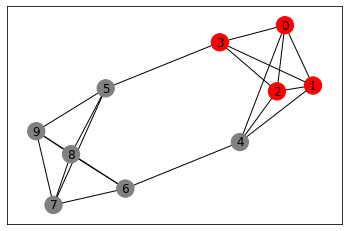

coef: 0.005096


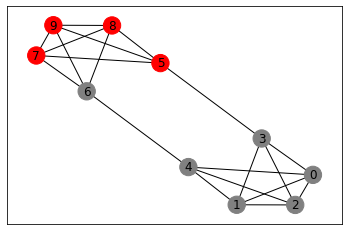

coef: 0.003175


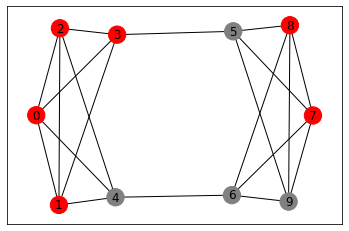

coef: 0.003175


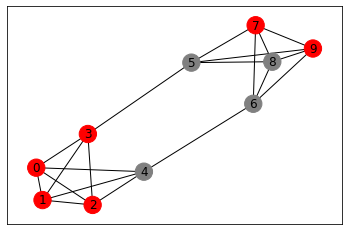

In [28]:
import matplotlib.pyplot as plt
for i in range(20):
    print("coef:",sorted_x_i_solutions[i][1])
    color_nodes_by_string(G, sorted_x_i_solutions[i][0])

In [29]:
# Step 5: Construct the QAOA operator for two layers
# Note: You can adjust the number of layers as needed
angles = np.array([2,6,5,6,6,5,6,2])*np.pi/8
op = qaoa.construct_QAOA_operator_term(angles, part_hamiltonian=H1)


In [30]:
# from QAOA_locality import count_solutions_XI

In [31]:
# Step 6: Count the X/I solutions and other statistics
x_i_solutions, max_locality, avg_locality, num_solutions = count_solutions_XI(op, tol=1e-6)


In [32]:
print("\nX/I Solutions:")
for i in x_i_solutions:
    print(i)
print("Number of X/I Solutions:", num_solutions)
print("Maximum Locality:", max_locality)
print("Average Locality:", avg_locality)


X/I Solutions:
('[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]', 0.03125)
('[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]', 0.03125)
('[1, 1, 0, 1, 0, 0, 0, 0, 0, 0]', -0.015625)
('[1, 0, 1, 1, 0, 0, 0, 0, 0, 0]', -0.015625)
('[0, 1, 1, 1, 0, 0, 0, 0, 0, 0]', -0.015625)
('[0, 0, 0, 0, 0, 1, 0, 1, 1, 0]', -0.015625)
('[0, 0, 0, 0, 0, 1, 0, 1, 0, 1]', -0.015625)
('[0, 0, 0, 0, 0, 1, 0, 0, 1, 1]', -0.015625)
Number of X/I Solutions: 8
Maximum Locality: 3
Average Locality: 2.5


In [34]:
# Sort by the absolute value of the coefficient
sorted_x_i_solutions = sorted(x_i_solutions, key=lambda x: abs(x[1]), reverse=True)

# Print the sorted list
for solution in sorted_x_i_solutions:
    print(solution)

('[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]', 0.03125)
('[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]', 0.03125)
('[1, 1, 0, 1, 0, 0, 0, 0, 0, 0]', -0.015625)
('[1, 0, 1, 1, 0, 0, 0, 0, 0, 0]', -0.015625)
('[0, 1, 1, 1, 0, 0, 0, 0, 0, 0]', -0.015625)
('[0, 0, 0, 0, 0, 1, 0, 1, 1, 0]', -0.015625)
('[0, 0, 0, 0, 0, 1, 0, 1, 0, 1]', -0.015625)
('[0, 0, 0, 0, 0, 1, 0, 0, 1, 1]', -0.015625)


coef: 0.03125


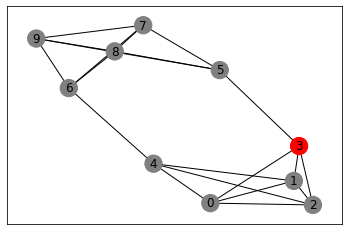

coef: 0.03125


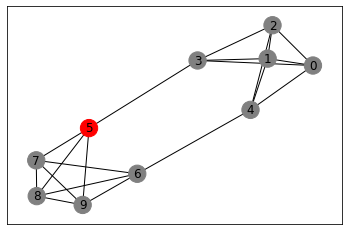

coef: -0.015625


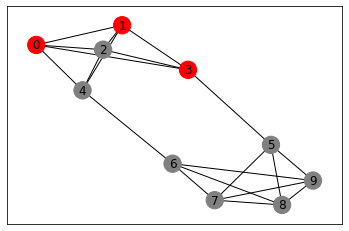

coef: -0.015625


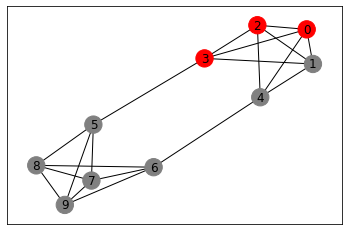

coef: -0.015625


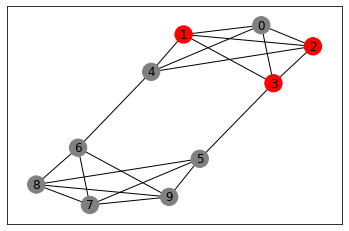

coef: -0.015625


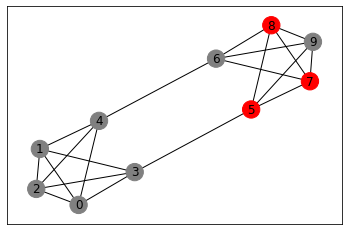

coef: -0.015625


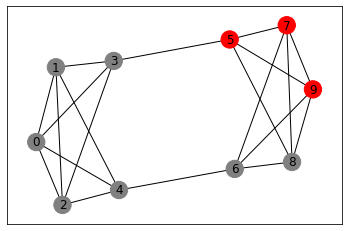

coef: -0.015625


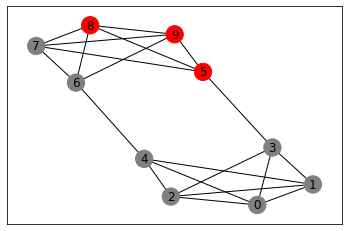

IndexError: list index out of range

In [35]:
import matplotlib.pyplot as plt
for i in range(20):
    print("coef:",sorted_x_i_solutions[i][1])
    color_nodes_by_string(G, sorted_x_i_solutions[i][0])

# 3, 0


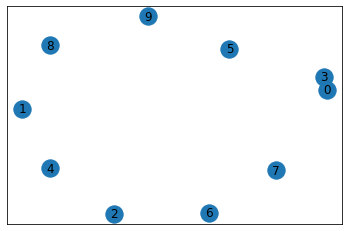

In [10]:
# Step 3: Create a subgraph for a smaller problem, i.e. term of the Hamilotian.
G1 = nx.Graph()
G1.add_nodes_from(range(10)) # Note that numeration should be the same
G1.add_edge(0, 3)

# Visualize the subgraph (optional)
nx.draw_networkx(G1)
# Step 4: Create the Hamiltonian for the subgraph
H1 = Graph_to_Hamiltonian(nx.adjacency_matrix(G1).todense().tolist())


In [11]:
# Step 5: Construct the QAOA operator for two layers
# Note: You can adjust the number of layers as needed
angles = np.random.rand(qaoa.p*2) * np.pi
op = qaoa.construct_QAOA_operator_term(angles, part_hamiltonian=H1)



In [12]:
# Step 6: Count the X/I solutions and other statistics
x_i_solutions, max_locality, avg_locality, num_solutions = count_solutions_XI(op, tol=1e-6)


In [13]:
print("\nX/I Solutions:")
for i in x_i_solutions:
    print(i)
print("Number of X/I Solutions:", num_solutions)
print("Maximum Locality:", max_locality)
print("Average Locality:", avg_locality)


X/I Solutions:
('[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]', -0.012498)
('[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]', 0.006267)
('[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]', 0.006267)
('[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]', -0.000336)
('[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]', -0.003656)
('[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]', -0.00145)
('[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]', 6.8e-05)
('[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]', 0.000564)
('[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]', 0.000564)
('[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]', 0.000564)
('[1, 1, 0, 0, 0, 0, 0, 0, 0, 0]', 0.013146)
('[1, 0, 1, 0, 0, 0, 0, 0, 0, 0]', 0.013146)
('[1, 0, 0, 1, 0, 0, 0, 0, 0, 0]', 0.00572)
('[1, 0, 0, 0, 1, 0, 0, 0, 0, 0]', 0.012201)
('[1, 0, 0, 0, 0, 1, 0, 0, 0, 0]', 0.000107)
('[1, 0, 0, 0, 0, 0, 1, 0, 0, 0]', 3.2e-05)
('[1, 0, 0, 0, 0, 0, 0, 1, 0, 0]', 2.4e-05)
('[1, 0, 0, 0, 0, 0, 0, 0, 1, 0]', 2.4e-05)
('[1, 0, 0, 0, 0, 0, 0, 0, 0, 1]', 2.4e-05)
('[0, 1, 1, 0, 0, 0, 0, 0, 0, 0]', 0.014849)
('[0, 1, 0, 1, 0, 0, 0, 0, 0, 0]', -0.002719)
('[0, 1, 0, 0, 1, 0, 0, 0, 0, 0]', -0.003

In [14]:
# Sort by the absolute value of the coefficient
sorted_x_i_solutions = sorted(x_i_solutions, key=lambda x: abs(x[1]), reverse=True)

# Print the sorted list
for solution in sorted_x_i_solutions:
    print(solution)

('[1, 0, 0, 1, 1, 1, 0, 1, 1, 1]', 0.025908)
('[1, 0, 0, 1, 1, 1, 1, 0, 0, 0]', -0.024122)
('[0, 1, 1, 1, 0, 0, 0, 0, 0, 0]', 0.019208)
('[0, 1, 1, 0, 0, 0, 0, 0, 0, 0]', 0.014849)
('[1, 1, 0, 0, 0, 0, 0, 0, 0, 0]', 0.013146)
('[1, 0, 1, 0, 0, 0, 0, 0, 0, 0]', 0.013146)
('[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]', -0.012498)
('[1, 0, 0, 0, 1, 0, 0, 0, 0, 0]', 0.012201)
('[1, 1, 1, 1, 1, 1, 0, 1, 1, 1]', -0.01077)
('[1, 0, 0, 1, 1, 0, 0, 0, 0, 0]', -0.006978)
('[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]', 0.006267)
('[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]', 0.006267)
('[1, 0, 0, 1, 0, 0, 0, 0, 0, 0]', 0.00572)
('[1, 0, 0, 1, 0, 1, 1, 0, 0, 0]', 0.005007)
('[0, 1, 0, 0, 1, 0, 0, 0, 0, 0]', -0.003844)
('[0, 0, 1, 0, 1, 0, 0, 0, 0, 0]', -0.003844)
('[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]', -0.003656)
('[0, 1, 0, 1, 1, 1, 0, 1, 1, 1]', -0.00357)
('[0, 0, 1, 1, 1, 1, 0, 1, 1, 1]', -0.00357)
('[0, 1, 1, 1, 1, 0, 0, 0, 0, 0]', -0.003555)
('[1, 1, 0, 1, 1, 1, 1, 0, 0, 0]', -0.003281)
('[1, 0, 1, 1, 1, 1, 1, 0, 0, 0]', -0.003281)
('

('[1, 0, 1, 1, 1, 0, 1, 0, 0, 0]', 4e-06)
('[0, 1, 1, 1, 1, 0, 1, 0, 0, 0]', 4e-06)
('[0, 1, 0, 1, 1, 0, 1, 1, 0, 0]', 4e-06)
('[0, 1, 0, 1, 1, 0, 1, 0, 1, 0]', 4e-06)
('[0, 1, 0, 1, 1, 0, 1, 0, 0, 1]', 4e-06)
('[0, 0, 1, 1, 1, 0, 1, 1, 0, 0]', 4e-06)
('[0, 0, 1, 1, 1, 0, 1, 0, 1, 0]', 4e-06)
('[0, 0, 1, 1, 1, 0, 1, 0, 0, 1]', 4e-06)
('[1, 1, 0, 1, 0, 0, 1, 1, 1, 0]', -4e-06)
('[1, 1, 0, 1, 0, 0, 1, 1, 0, 1]', -4e-06)
('[1, 1, 0, 1, 0, 0, 1, 0, 1, 1]', -4e-06)
('[1, 0, 1, 1, 0, 0, 1, 1, 1, 0]', -4e-06)
('[1, 0, 1, 1, 0, 0, 1, 1, 0, 1]', -4e-06)
('[1, 0, 1, 1, 0, 0, 1, 0, 1, 1]', -4e-06)
('[0, 1, 0, 1, 1, 1, 1, 1, 0, 0]', 4e-06)
('[0, 1, 0, 1, 1, 1, 1, 0, 1, 0]', 4e-06)
('[0, 1, 0, 1, 1, 1, 1, 0, 0, 1]', 4e-06)
('[0, 0, 1, 1, 1, 1, 1, 1, 0, 0]', 4e-06)
('[0, 0, 1, 1, 1, 1, 1, 0, 1, 0]', 4e-06)
('[0, 0, 1, 1, 1, 1, 1, 0, 0, 1]', 4e-06)
('[1, 1, 0, 0, 0, 1, 1, 1, 1, 1]', -4e-06)
('[1, 0, 1, 0, 0, 1, 1, 1, 1, 1]', -4e-06)
('[0, 1, 1, 0, 1, 0, 0, 1, 0, 0]', 3e-06)
('[0, 1, 1, 0, 1, 0, 0, 0,

coef: 0.025908


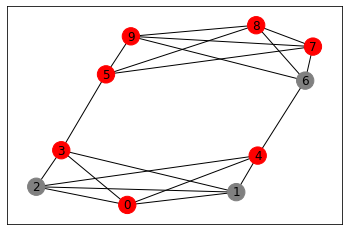

coef: -0.024122


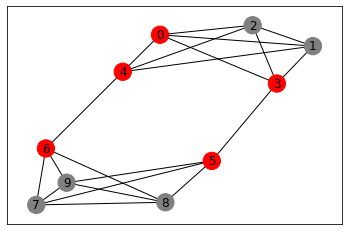

coef: 0.019208


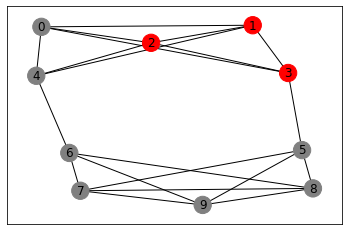

coef: 0.014849


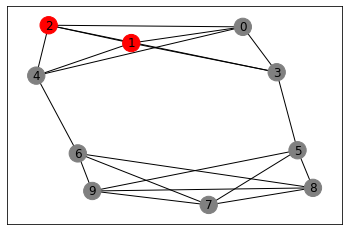

coef: 0.013146


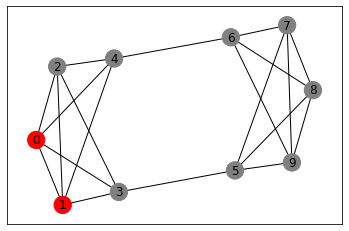

coef: 0.013146


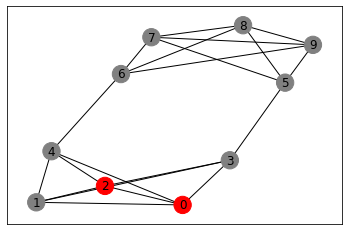

coef: -0.012498


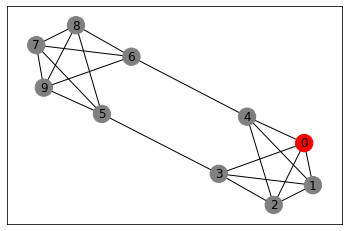

coef: 0.012201


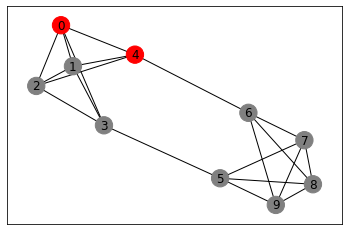

coef: -0.01077


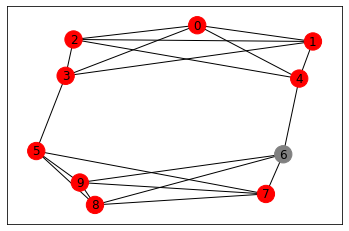

coef: -0.006978


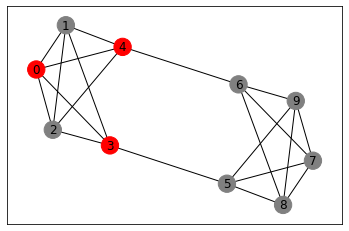

coef: 0.006267


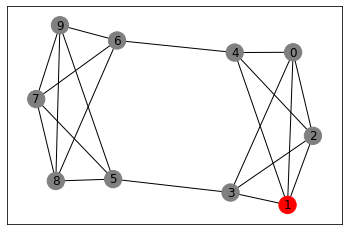

coef: 0.006267


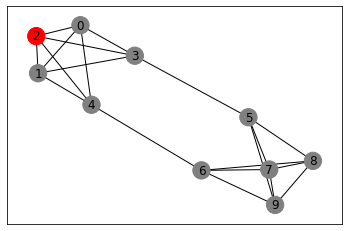

coef: 0.00572


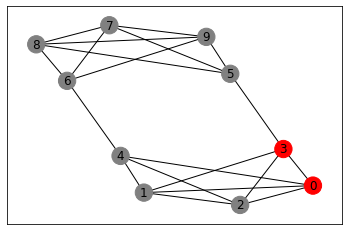

coef: 0.005007


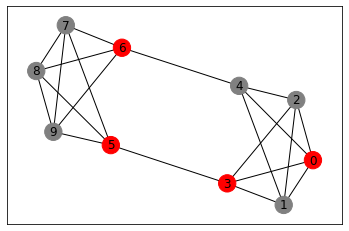

coef: -0.003844


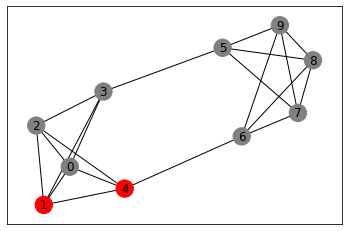

coef: -0.003844


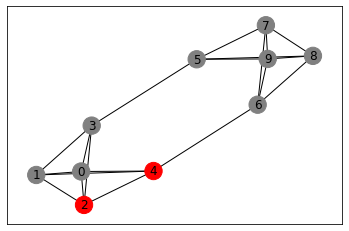

coef: -0.003656


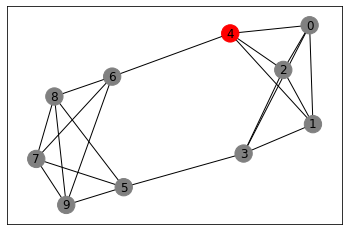

coef: -0.00357


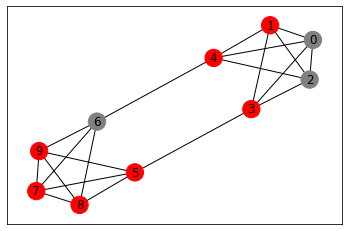

coef: -0.00357


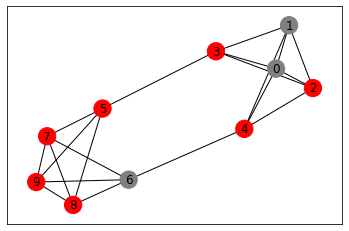

coef: -0.003555


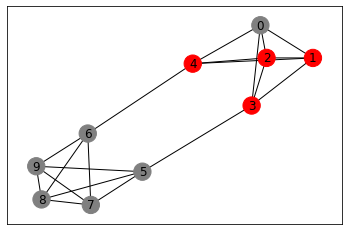

In [15]:
import matplotlib.pyplot as plt
for i in range(20):
    print("coef:",sorted_x_i_solutions[i][1])
    color_nodes_by_string(G, sorted_x_i_solutions[i][0])

In [16]:
# Step 5: Construct the QAOA operator for two layers
# Note: You can adjust the number of layers as needed
angles = np.array([2,6,5,6,6,5,6,2])*np.pi/8
op = qaoa.construct_QAOA_operator_term(angles, part_hamiltonian=H1)


In [17]:
# Step 6: Count the X/I solutions and other statistics
x_i_solutions, max_locality, avg_locality, num_solutions = count_solutions_XI(op, tol=1e-6)


In [18]:
print("\nX/I Solutions:")
for i in x_i_solutions:
    print(i)
print("Number of X/I Solutions:", num_solutions)
print("Maximum Locality:", max_locality)
print("Average Locality:", avg_locality)


X/I Solutions:
('[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]', 0.03125)
('[1, 0, 0, 0, 0, 0, 0, 1, 1, 0]', -0.015625)
('[1, 0, 0, 0, 0, 0, 0, 1, 0, 1]', -0.015625)
('[1, 0, 0, 0, 0, 0, 0, 0, 1, 1]', -0.015625)
('[0, 1, 1, 1, 0, 0, 0, 0, 0, 0]', -0.015625)
('[0, 1, 0, 0, 1, 1, 1, 0, 0, 0]', 0.015625)
('[0, 0, 1, 0, 1, 1, 1, 0, 0, 0]', 0.015625)
('[0, 1, 1, 1, 0, 0, 0, 1, 1, 0]', 0.03125)
('[0, 1, 1, 1, 0, 0, 0, 1, 0, 1]', 0.03125)
('[0, 1, 1, 1, 0, 0, 0, 0, 1, 1]', 0.03125)
('[1, 1, 0, 1, 1, 1, 1, 0, 0, 0]', -0.015625)
('[1, 0, 1, 1, 1, 1, 1, 0, 0, 0]', -0.015625)
('[0, 1, 0, 0, 1, 1, 1, 1, 1, 0]', -0.03125)
('[0, 1, 0, 0, 1, 1, 1, 1, 0, 1]', -0.03125)
('[0, 1, 0, 0, 1, 1, 1, 0, 1, 1]', -0.03125)
('[0, 0, 1, 0, 1, 1, 1, 1, 1, 0]', -0.03125)
('[0, 0, 1, 0, 1, 1, 1, 1, 0, 1]', -0.03125)
('[0, 0, 1, 0, 1, 1, 1, 0, 1, 1]', -0.03125)
('[1, 1, 0, 1, 1, 1, 1, 1, 1, 0]', 0.007812)
('[1, 1, 0, 1, 1, 1, 1, 1, 0, 1]', 0.007812)
('[1, 1, 0, 1, 1, 1, 1, 0, 1, 1]', 0.007812)
('[1, 0, 1, 1, 1, 1, 1, 1, 1, 0]', 0.

In [19]:
# Sort by the absolute value of the coefficient
sorted_x_i_solutions = sorted(x_i_solutions, key=lambda x: abs(x[1]), reverse=True)

# Print the sorted list
for solution in sorted_x_i_solutions:
    print(solution)

('[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]', 0.03125)
('[0, 1, 1, 1, 0, 0, 0, 1, 1, 0]', 0.03125)
('[0, 1, 1, 1, 0, 0, 0, 1, 0, 1]', 0.03125)
('[0, 1, 1, 1, 0, 0, 0, 0, 1, 1]', 0.03125)
('[0, 1, 0, 0, 1, 1, 1, 1, 1, 0]', -0.03125)
('[0, 1, 0, 0, 1, 1, 1, 1, 0, 1]', -0.03125)
('[0, 1, 0, 0, 1, 1, 1, 0, 1, 1]', -0.03125)
('[0, 0, 1, 0, 1, 1, 1, 1, 1, 0]', -0.03125)
('[0, 0, 1, 0, 1, 1, 1, 1, 0, 1]', -0.03125)
('[0, 0, 1, 0, 1, 1, 1, 0, 1, 1]', -0.03125)
('[1, 0, 0, 0, 0, 0, 0, 1, 1, 0]', -0.015625)
('[1, 0, 0, 0, 0, 0, 0, 1, 0, 1]', -0.015625)
('[1, 0, 0, 0, 0, 0, 0, 0, 1, 1]', -0.015625)
('[0, 1, 1, 1, 0, 0, 0, 0, 0, 0]', -0.015625)
('[0, 1, 0, 0, 1, 1, 1, 0, 0, 0]', 0.015625)
('[0, 0, 1, 0, 1, 1, 1, 0, 0, 0]', 0.015625)
('[1, 1, 0, 1, 1, 1, 1, 0, 0, 0]', -0.015625)
('[1, 0, 1, 1, 1, 1, 1, 0, 0, 0]', -0.015625)
('[1, 1, 0, 1, 1, 1, 1, 1, 1, 0]', 0.007812)
('[1, 1, 0, 1, 1, 1, 1, 1, 0, 1]', 0.007812)
('[1, 1, 0, 1, 1, 1, 1, 0, 1, 1]', 0.007812)
('[1, 0, 1, 1, 1, 1, 1, 1, 1, 0]', 0.007812)
('[1, 0,

coef: 0.03125


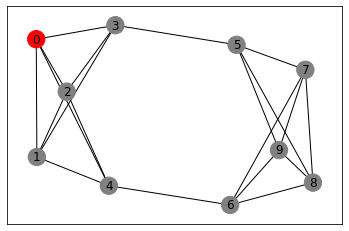

coef: 0.03125


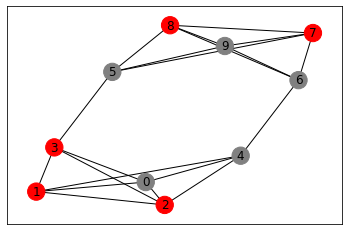

coef: 0.03125


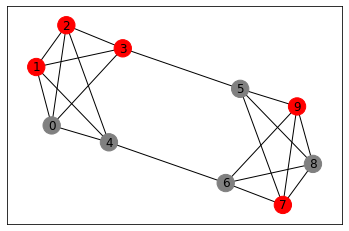

coef: 0.03125


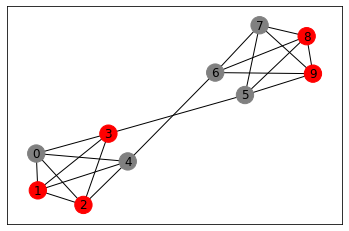

coef: -0.03125


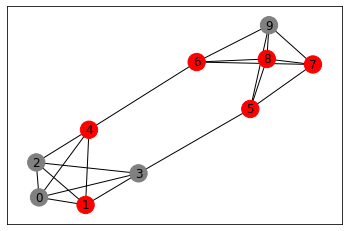

coef: -0.03125


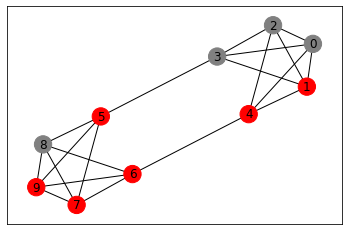

coef: -0.03125


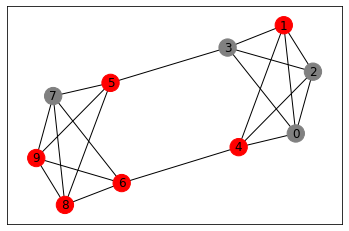

coef: -0.03125


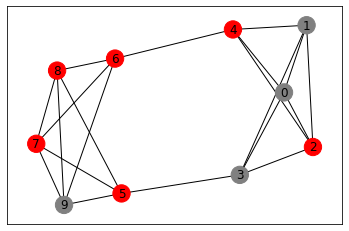

coef: -0.03125


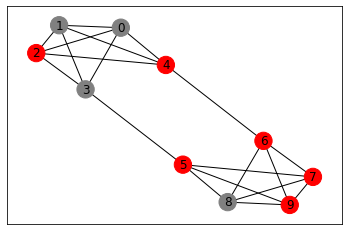

coef: -0.03125


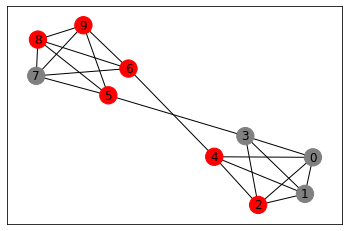

coef: -0.015625


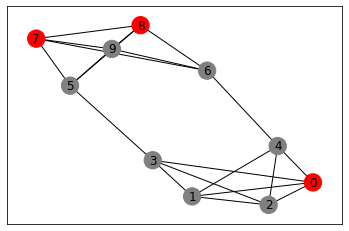

coef: -0.015625


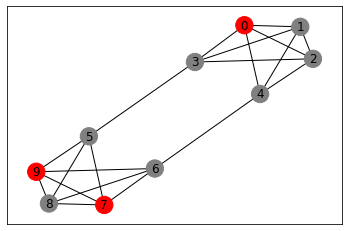

coef: -0.015625


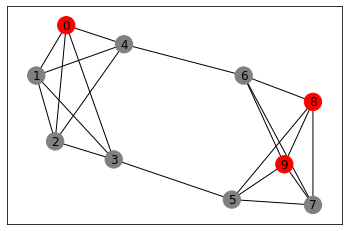

coef: -0.015625


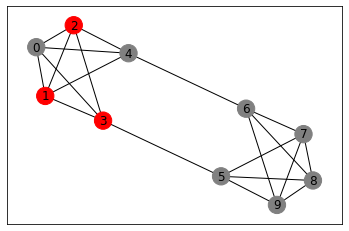

coef: 0.015625


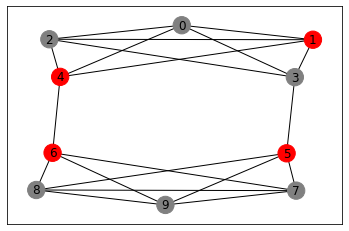

coef: 0.015625


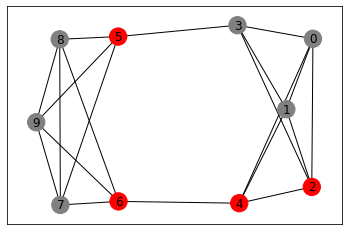

coef: -0.015625


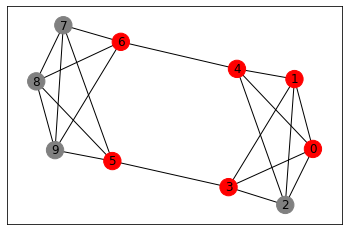

coef: -0.015625


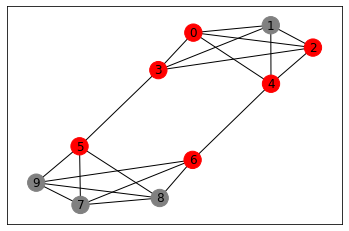

coef: 0.007812


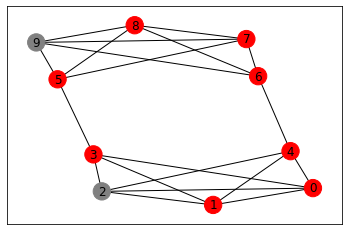

coef: 0.007812


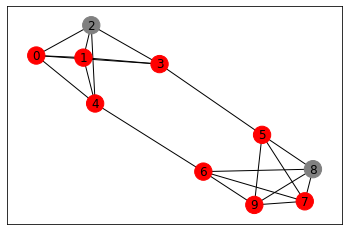

In [20]:
import matplotlib.pyplot as plt
for i in range(20):
    print("coef:",sorted_x_i_solutions[i][1])
    color_nodes_by_string(G, sorted_x_i_solutions[i][0])

# 1,0

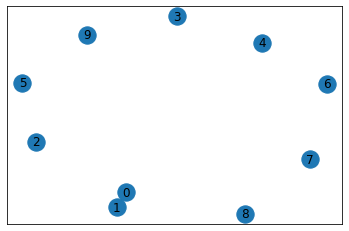

In [21]:
# Step 3: Create a subgraph for a smaller problem, i.e. term of the Hamilotian.
G1 = nx.Graph()
G1.add_nodes_from(range(10)) # Note that numeration should be the same
G1.add_edge(0, 1)

# Visualize the subgraph (optional)
nx.draw_networkx(G1)
# Step 4: Create the Hamiltonian for the subgraph
H1 = Graph_to_Hamiltonian(nx.adjacency_matrix(G1).todense().tolist())


In [22]:
# Step 5: Construct the QAOA operator for two layers
# Note: You can adjust the number of layers as needed
angles = np.random.rand(qaoa.p*2) * np.pi
op = qaoa.construct_QAOA_operator_term(angles, part_hamiltonian=H1)



In [23]:
# Step 6: Count the X/I solutions and other statistics
x_i_solutions, max_locality, avg_locality, num_solutions = count_solutions_XI(op, tol=1e-6)


In [24]:
print("\nX/I Solutions:")
for i in x_i_solutions:
    print(i)
print("Number of X/I Solutions:", num_solutions)
print("Maximum Locality:", max_locality)
print("Average Locality:", avg_locality)


X/I Solutions:
('[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]', 0.028568)
('[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]', 0.028568)
('[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]', -0.020626)
('[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]', 0.010257)
('[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]', 0.010257)
('[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]', -0.000313)
('[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]', -0.000313)
('[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]', 0.00023)
('[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]', 0.00023)
('[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]', 0.00023)
('[1, 1, 0, 0, 0, 0, 0, 0, 0, 0]', 0.42676)
('[1, 0, 1, 0, 0, 0, 0, 0, 0, 0]', -0.034539)
('[1, 0, 0, 1, 0, 0, 0, 0, 0, 0]', -0.021304)
('[1, 0, 0, 0, 1, 0, 0, 0, 0, 0]', -0.021304)
('[1, 0, 0, 0, 0, 1, 0, 0, 0, 0]', -0.000575)
('[1, 0, 0, 0, 0, 0, 1, 0, 0, 0]', -0.000575)
('[1, 0, 0, 0, 0, 0, 0, 1, 0, 0]', -9.9e-05)
('[1, 0, 0, 0, 0, 0, 0, 0, 1, 0]', -9.9e-05)
('[1, 0, 0, 0, 0, 0, 0, 0, 0, 1]', -9.9e-05)
('[0, 1, 1, 0, 0, 0, 0, 0, 0, 0]', -0.034539)
('[0, 1, 0, 1, 0, 0, 0, 0, 0, 0]', -0.021304)
('[0, 1, 0, 0, 1, 0, 0, 0, 0, 0]'

In [25]:
# Sort by the absolute value of the coefficient
sorted_x_i_solutions = sorted(x_i_solutions, key=lambda x: abs(x[1]), reverse=True)

# Print the sorted list
for solution in sorted_x_i_solutions:
    print(solution)

('[1, 1, 0, 0, 0, 0, 0, 0, 0, 0]', 0.42676)
('[1, 0, 1, 0, 0, 0, 0, 0, 0, 0]', -0.034539)
('[0, 1, 1, 0, 0, 0, 0, 0, 0, 0]', -0.034539)
('[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]', 0.028568)
('[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]', 0.028568)
('[1, 0, 0, 1, 0, 0, 0, 0, 0, 0]', -0.021304)
('[1, 0, 0, 0, 1, 0, 0, 0, 0, 0]', -0.021304)
('[0, 1, 0, 1, 0, 0, 0, 0, 0, 0]', -0.021304)
('[0, 1, 0, 0, 1, 0, 0, 0, 0, 0]', -0.021304)
('[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]', -0.020626)
('[1, 1, 0, 1, 1, 0, 0, 0, 0, 0]', -0.020206)
('[1, 1, 0, 1, 0, 0, 0, 0, 0, 0]', 0.0151)
('[1, 1, 0, 0, 1, 0, 0, 0, 0, 0]', 0.0151)
('[0, 0, 1, 1, 1, 0, 0, 0, 0, 0]', -0.013154)
('[1, 1, 0, 1, 1, 1, 1, 0, 0, 0]', -0.012645)
('[1, 0, 1, 1, 0, 0, 0, 0, 0, 0]', 0.010299)
('[1, 0, 1, 0, 1, 0, 0, 0, 0, 0]', 0.010299)
('[0, 1, 1, 1, 0, 0, 0, 0, 0, 0]', 0.010299)
('[0, 1, 1, 0, 1, 0, 0, 0, 0, 0]', 0.010299)
('[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]', 0.010257)
('[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]', 0.010257)
('[1, 1, 1, 1, 0, 0, 0, 0, 0, 0]', -0.009821)
('[1

('[1, 0, 0, 1, 1, 0, 0, 1, 1, 1]', -0.000121)
('[0, 1, 0, 1, 1, 0, 0, 1, 1, 1]', -0.000121)
('[1, 1, 1, 1, 0, 0, 1, 1, 1, 0]', -0.000121)
('[1, 1, 1, 1, 0, 0, 1, 1, 0, 1]', -0.000121)
('[1, 1, 1, 1, 0, 0, 1, 0, 1, 1]', -0.000121)
('[1, 1, 1, 0, 1, 1, 0, 1, 1, 0]', -0.000121)
('[1, 1, 1, 0, 1, 1, 0, 1, 0, 1]', -0.000121)
('[1, 1, 1, 0, 1, 1, 0, 0, 1, 1]', -0.000121)
('[1, 0, 1, 0, 0, 0, 0, 1, 1, 0]', 0.000114)
('[1, 0, 1, 0, 0, 0, 0, 1, 0, 1]', 0.000114)
('[1, 0, 1, 0, 0, 0, 0, 0, 1, 1]', 0.000114)
('[0, 1, 1, 0, 0, 0, 0, 1, 1, 0]', 0.000114)
('[0, 1, 1, 0, 0, 0, 0, 1, 0, 1]', 0.000114)
('[0, 1, 1, 0, 0, 0, 0, 0, 1, 1]', 0.000114)
('[1, 0, 1, 1, 0, 0, 1, 1, 0, 0]', -0.000114)
('[1, 0, 1, 1, 0, 0, 1, 0, 1, 0]', -0.000114)
('[1, 0, 1, 1, 0, 0, 1, 0, 0, 1]', -0.000114)
('[1, 0, 1, 0, 1, 1, 0, 1, 0, 0]', -0.000114)
('[1, 0, 1, 0, 1, 1, 0, 0, 1, 0]', -0.000114)
('[1, 0, 1, 0, 1, 1, 0, 0, 0, 1]', -0.000114)
('[0, 1, 1, 1, 0, 0, 1, 1, 0, 0]', -0.000114)
('[0, 1, 1, 1, 0, 0, 1, 0, 1, 0]', -0.00

coef: 0.42676


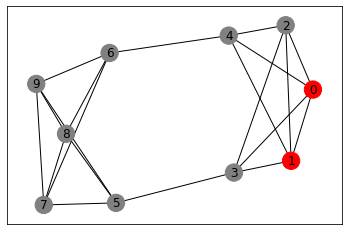

coef: -0.034539


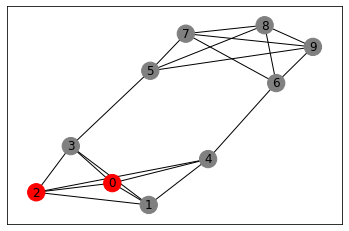

coef: -0.034539


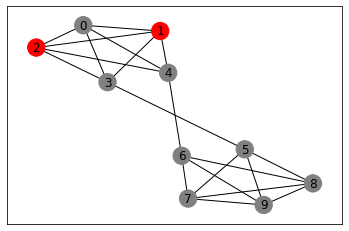

coef: 0.028568


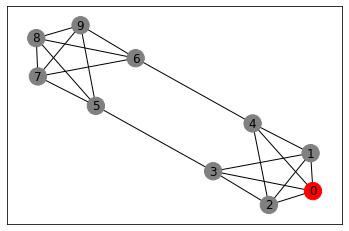

coef: 0.028568


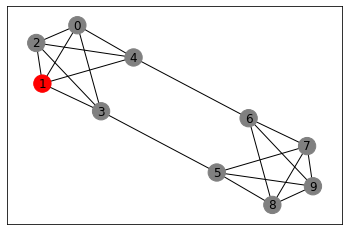

coef: -0.021304


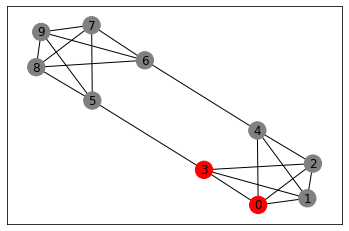

coef: -0.021304


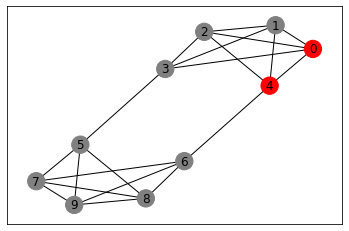

coef: -0.021304


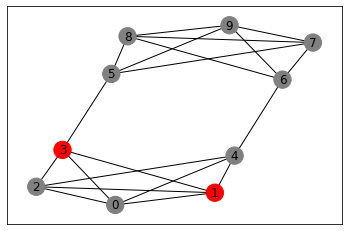

coef: -0.021304


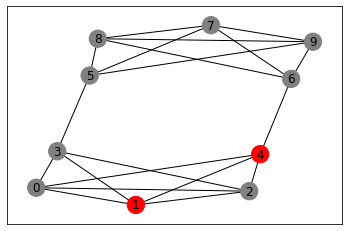

coef: -0.020626


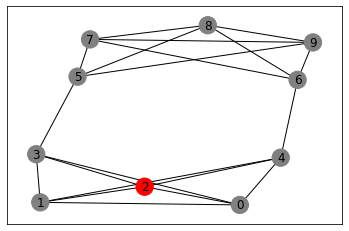

coef: -0.020206


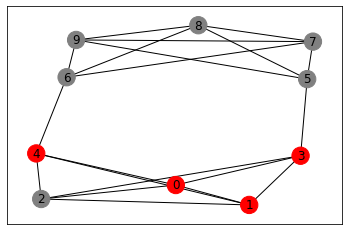

coef: 0.0151


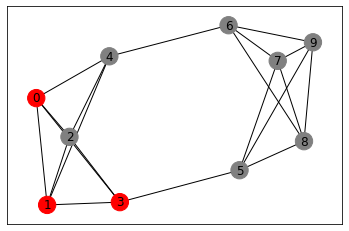

coef: 0.0151


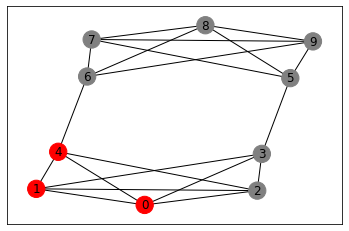

coef: -0.013154


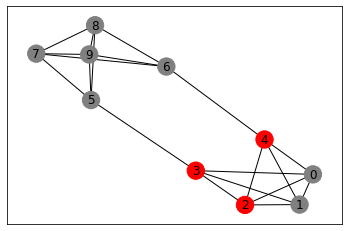

coef: -0.012645


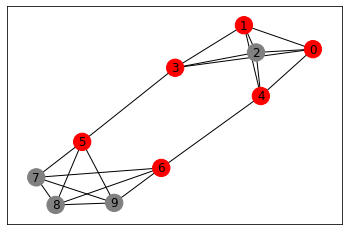

coef: 0.010299


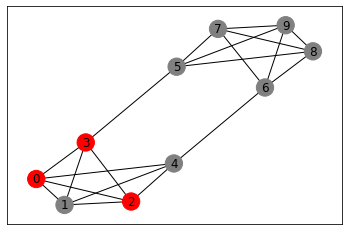

coef: 0.010299


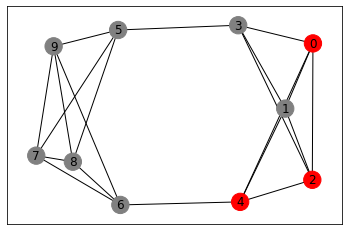

coef: 0.010299


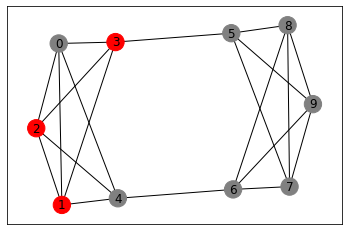

coef: 0.010299


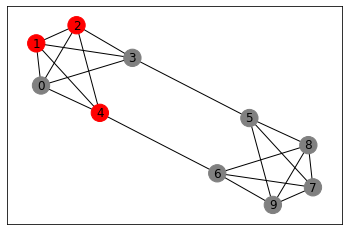

coef: 0.010257


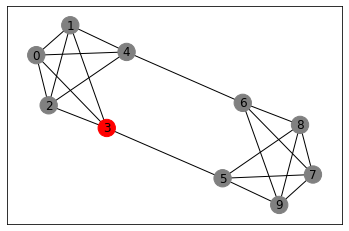

In [26]:
import matplotlib.pyplot as plt
for i in range(20):
    print("coef:",sorted_x_i_solutions[i][1])
    color_nodes_by_string(G, sorted_x_i_solutions[i][0])

In [27]:
# Step 5: Construct the QAOA operator for two layers
# Note: You can adjust the number of layers as needed
angles = np.array([2,6,5,6,6,5,6,2])*np.pi/8
op = qaoa.construct_QAOA_operator_term(angles, part_hamiltonian=H1)

In [28]:
# Step 6: Count the X/I solutions and other statistics
x_i_solutions, max_locality, avg_locality, num_solutions = count_solutions_XI(op, tol=1e-6)


In [29]:
print("\nX/I Solutions:")
for i in x_i_solutions:
    print(i)
print("Number of X/I Solutions:", num_solutions)
print("Maximum Locality:", max_locality)
print("Average Locality:", avg_locality)


X/I Solutions:
('[1, 1, 0, 0, 0, 0, 0, 0, 0, 0]', 0.25)
('[1, 0, 0, 1, 1, 1, 1, 0, 0, 0]', -0.125)
('[0, 1, 0, 1, 1, 1, 1, 0, 0, 0]', -0.125)
Number of X/I Solutions: 3
Maximum Locality: 5
Average Locality: 4.0


In [30]:
# Sort by the absolute value of the coefficient
sorted_x_i_solutions = sorted(x_i_solutions, key=lambda x: abs(x[1]), reverse=True)

# Print the sorted list
for solution in sorted_x_i_solutions:
    print(solution)

('[1, 1, 0, 0, 0, 0, 0, 0, 0, 0]', 0.25)
('[1, 0, 0, 1, 1, 1, 1, 0, 0, 0]', -0.125)
('[0, 1, 0, 1, 1, 1, 1, 0, 0, 0]', -0.125)


coef: 0.25


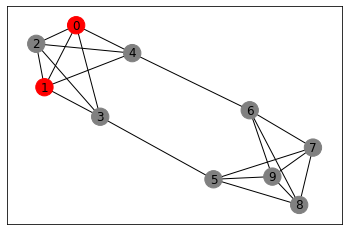

coef: -0.125


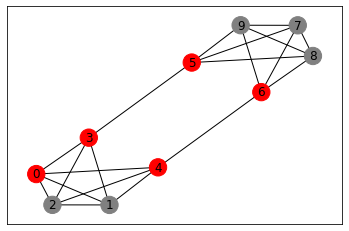

coef: -0.125


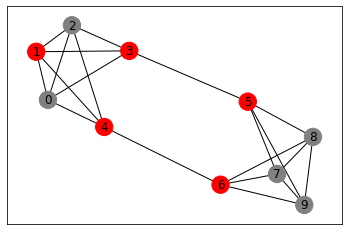

IndexError: list index out of range

In [31]:
import matplotlib.pyplot as plt
for i in range(20):
    print("coef:",sorted_x_i_solutions[i][1])
    color_nodes_by_string(G, sorted_x_i_solutions[i][0])